<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 129 · Time Series & Forecasting</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Volatility &amp; Advanced Models</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">Read ACF and PACF to pick model orders, cross-check stationarity with ADF, Phillips-Perron, and KPSS, model volatility clustering with ARCH/GARCH, and relate one series to another with Granger causality and ARDL, on three years of daily market and stock returns.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Volatility &amp; Advanced Models
The last chapter forecast the *level* of a series. This one adds the rest of the professional toolkit: reading **ACF and PACF** to choose model orders, three **unit-root tests** that cross-check stationarity, **ARCH/GARCH** for series whose *variance* moves (financial returns), and two tools for **relationships between series**, **Granger causality** and **ARDL**. We work on three years of daily market and stock returns.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ardl import ARDL
import warnings; warnings.filterwarnings('ignore')
try:
    from arch import arch_model; from arch.unitroot import PhillipsPerron
except ImportError:
    import subprocess, sys; subprocess.run([sys.executable,'-m','pip','install','-q','arch']); from arch import arch_model; from arch.unitroot import PhillipsPerron

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">REAL DATA &#183; DAILY RETURNS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A market index and one stock</div>
<div style="color:#4a5578;margin-top:6px">756 trading days; the stock reacts to the market with a lag.</div>
</div>

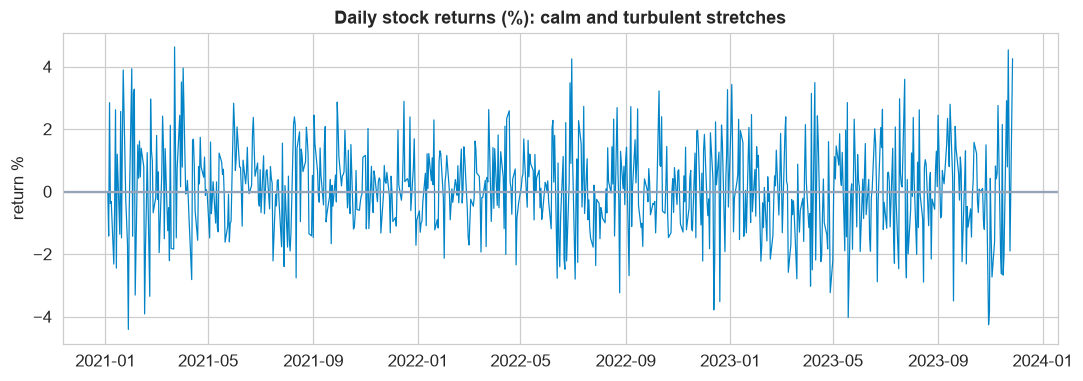

notice the QUIET periods and the BURSTS of big swings -> volatility clustering, the theme of this chapter


In [3]:
try: raw = pd.read_excel('../../data/ch129_daily_returns.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'ch129_daily_returns.xlsx', sheet_name='Data')
raw['date']=pd.to_datetime(raw['date']); df = raw.set_index('date')
mkt, stock = df['market_return'], df['stock_return']
fig,ax=plt.subplots(figsize=(10,3.6)); ax.plot(stock.index, stock, color=EM, lw=0.8)
ax.axhline(0,color=GREY); ax.set(title='Daily stock returns (%): calm and turbulent stretches', ylabel='return %'); plt.tight_layout(); plt.show()
print('notice the QUIET periods and the BURSTS of big swings -> volatility clustering, the theme of this chapter')

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 1 &#183; ACF &amp; PACF</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How to read the correlograms</div>
<div style="color:#4a5578;margin-top:6px">They tell you the order, and where the signal hides.</div>
</div>

The **ACF** (autocorrelation) and **PACF** (partial autocorrelation) are the classic order-picking tools. Rule of thumb: an **AR(p)** process has a PACF that cuts off after lag p; an **MA(q)** process has an ACF that cuts off after lag q.

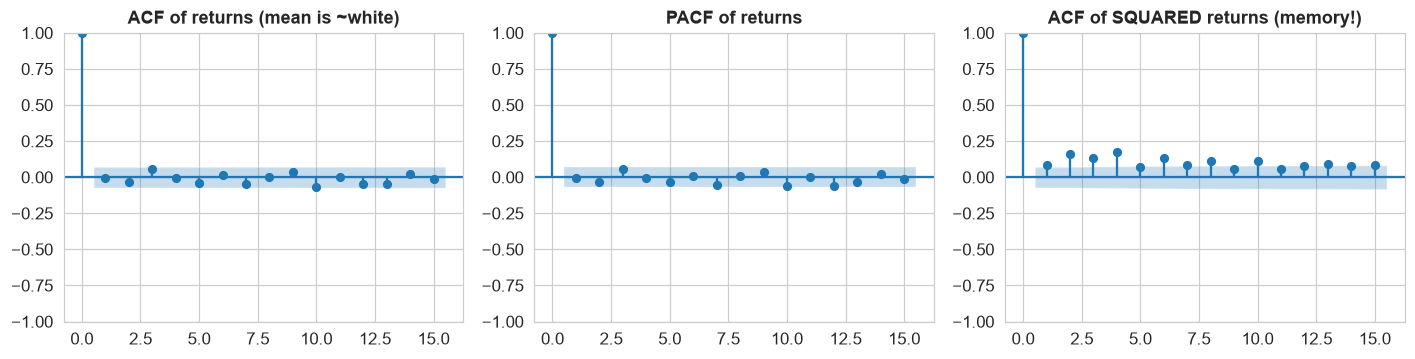

ACF(returns) lag1 = -0.01 (unpredictable in the mean)
ACF(returns^2) lag1 = 0.09 -> the VARIANCE has memory, even though the mean does not


In [4]:
fig,ax=plt.subplots(1,3,figsize=(13,3.4))
plot_acf(stock, lags=15, ax=ax[0]); ax[0].set(title='ACF of returns (mean is ~white)')
plot_pacf(stock, lags=15, ax=ax[1], method='ywm'); ax[1].set(title='PACF of returns')
plot_acf((stock-stock.mean())**2, lags=15, ax=ax[2]); ax[2].set(title='ACF of SQUARED returns (memory!)')
plt.tight_layout(); plt.show()
print('ACF(returns) lag1 = %.2f (unpredictable in the mean)' % acf(stock,nlags=1)[1])
print('ACF(returns^2) lag1 = %.2f -> the VARIANCE has memory, even though the mean does not' % acf((stock-stock.mean())**2,nlags=1)[1])

The returns are essentially **white noise in the mean**, their ACF and PACF are flat, so you cannot predict tomorrow's return. But the **squared** returns show clear autocorrelation: big days follow big days. The signal is in the **variance**, not the level, and that is exactly what ARCH/GARCH models.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 2 &#183; UNIT-ROOT TESTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Three checks for stationarity</div>
<div style="color:#4a5578;margin-top:6px">Two share a null; one flips it, use them together.</div>
</div>

In [5]:
print('ADF  p = %.4f   (H0: has a unit root = NON-stationary)' % adfuller(stock)[1])
print('PP   p = %.4f   (H0: has a unit root = NON-stationary)' % PhillipsPerron(stock).pvalue)
print('KPSS p = %.4f   (H0: STATIONARY -- the opposite null)' % kpss(stock, regression='c', nlags='auto')[1])
print('\nADF and PP: small p -> reject non-stationary -> STATIONARY.')
print('KPSS: large p -> fail to reject stationary -> STATIONARY. All three agree.')

ADF  p = 0.0000   (H0: has a unit root = NON-stationary)
PP   p = 0.0000   (H0: has a unit root = NON-stationary)
KPSS p = 0.1000   (H0: STATIONARY -- the opposite null)

ADF and PP: small p -> reject non-stationary -> STATIONARY.
KPSS: large p -> fail to reject stationary -> STATIONARY. All three agree.


Stationarity is worth confirming with more than one lens. **ADF** and **Phillips-Perron (PP)** share the null &#8220;there is a unit root&#8221; (non-stationary), so a *small* p-value means stationary. **KPSS flips the null** to &#8220;stationary&#8221;, so a *large* p-value means stationary. Using ADF and KPSS together is the standard confirmatory pair: when they agree, you can trust the verdict. Returns are stationary (a price *level* would not be, you would difference it first).

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 3 &#183; ARCH &amp; GARCH</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Model the variance itself</div>
<div style="color:#4a5578;margin-top:6px">When volatility clusters, forecast the volatility.</div>
</div>

**ARCH/GARCH** models let today's variance depend on recent squared shocks and recent variance. **GARCH(1,1)** is the workhorse: <code>variance_t = omega + alpha &#183; shock&#178;_(t-1) + beta &#183; variance_(t-1)</code>. A high **alpha + beta** (near 1) means shocks to volatility fade slowly, the hallmark of markets.

omega = 0.096 | alpha[1] = 0.101 | beta[1] = 0.855
persistence alpha+beta = 0.957 (close to 1 -> volatility shocks are long-lived)


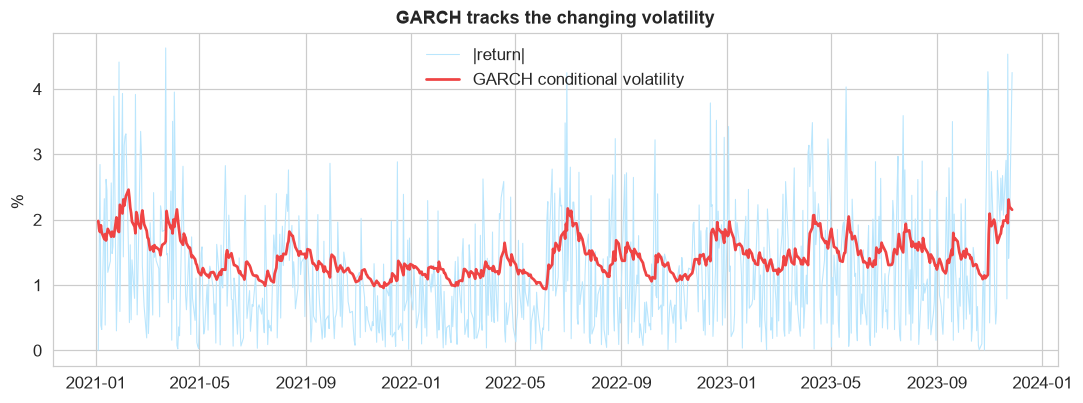

In [6]:
g = arch_model(stock, mean='Constant', vol='GARCH', p=1, q=1).fit(disp='off')
print('omega = %.3f | alpha[1] = %.3f | beta[1] = %.3f' % (g.params['omega'], g.params['alpha[1]'], g.params['beta[1]']))
print('persistence alpha+beta = %.3f (close to 1 -> volatility shocks are long-lived)' % (g.params['alpha[1]']+g.params['beta[1]']))
fig,ax=plt.subplots(figsize=(10,3.8)); ax.plot(stock.index, stock.abs(), color=LIGHT, lw=0.7, label='|return|')
ax.plot(g.conditional_volatility.index, g.conditional_volatility, color=RED, lw=1.8, label='GARCH conditional volatility')
ax.set(title='GARCH tracks the changing volatility', ylabel='% '); ax.legend(); plt.tight_layout(); plt.show()

The fitted **GARCH(1,1)** has persistence <strong>alpha + beta about 0.96</strong>, so a turbulent day raises expected volatility for many days after. The red line is the model's **conditional volatility**: it rises during the stormy stretches and falls in the calm ones, exactly the clustering we saw. This is what powers risk measures like Value-at-Risk, forecasting the *size* of moves, not their direction.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 4 &#183; GRANGER CAUSALITY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does one series help predict another?</div>
<div style="color:#4a5578;margin-top:6px">Predictive precedence, not proof of cause.</div>
</div>

In [7]:
print('Does the MARKET help predict the STOCK (beyond the stock\'s own past)?')
gm = grangercausalitytests(df[['stock_return','market_return']], maxlag=2, verbose=False)
print('  market -> stock  p(lag1) = %.4f  -> YES, significant' % gm[1][0]['ssr_ftest'][1])
print('Does the STOCK help predict the MARKET?')
gs = grangercausalitytests(df[['market_return','stock_return']], maxlag=2, verbose=False)
print('  stock -> market  p(lag1) = %.4f  -> no' % gs[1][0]['ssr_ftest'][1])

Does the MARKET help predict the STOCK (beyond the stock's own past)?
  market -> stock  p(lag1) = 0.0000  -> YES, significant
Does the STOCK help predict the MARKET?
  stock -> market  p(lag1) = 0.5596  -> no


**Granger causality** asks a narrow, testable question: does adding the past of series X improve the forecast of Y over Y's own past alone? Here the **market Granger-causes the stock** (p well below 0.05) but not the reverse, matching how the stock was built to lag the market. The crucial caveat: Granger causality is **predictive precedence, not true causation**, a common driver or a faster-reacting third series can produce it.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">DEMO 5 &#183; ARDL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Relate one series to another over time</div>
<div style="color:#4a5578;margin-top:6px">Its own lags plus another series' lags.</div>
</div>

In [8]:
ard = ARDL(stock, 1, df[['market_return']], 1).fit()     # 1 lag of stock, market at lag 0 and 1
mkt_now = ard.params.filter(like='market_return.L0').iloc[0]
mkt_lag = ard.params.filter(like='market_return.L1').iloc[0]
print('stock_return ~ own lag + market_return(today) + market_return(yesterday)')
print('  today\'s market coef    = %.3f' % mkt_now)
print('  yesterday\'s market coef = %.3f  (the lagged reaction Granger detected)' % mkt_lag)

stock_return ~ own lag + market_return(today) + market_return(yesterday)
  today's market coef    = 0.331
  yesterday's market coef = 0.290  (the lagged reaction Granger detected)


An **ARDL (AutoRegressive Distributed Lag)** model regresses a series on **its own lags** and on the **current and lagged values of another series**, a flexible way to model a dynamic relationship. Here the stock responds to the market **both today (about 0.33) and yesterday (about 0.29)**, quantifying the lead-lag link Granger only flagged. ARDL also underpins the **bounds test** for cointegration, checking whether two trending series move together in the long run.

## The advanced toolkit, in one view

1. **ACF / PACF** read the correlograms to choose AR and MA orders, and to find memory in the variance.
2. **Unit-root tests** confirm stationarity; ADF and PP share a null, KPSS flips it, use them together.
3. **ARCH / GARCH** model volatility clustering by forecasting the variance, not the level.
4. **Granger causality** tests whether one series helps predict another, predictive precedence, not proof of cause.
5. **ARDL** relates a series to its own past and another series' past, and supports a cointegration bounds test.

**The one idea to keep: once you can forecast the level, the advanced toolkit handles what basic models ignore, memory in the variance (GARCH) and relationships between series (Granger, ARDL), and every one of them still leans on stationarity and the ACF.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>